In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
autos = pd.read_csv("autos.csv", encoding='latin1', sep=';')
encuestados = pd.read_excel("encuestados.xlsx")

In [76]:
autos.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   marca_A                   200 non-null    str    
 1   modelo_A                  200 non-null    str    
 2   segmento_A                200 non-null    str    
 3   carroceria_A              200 non-null    str    
 4   combustible_A             200 non-null    str    
 5   transmision_A             200 non-null    str    
 6   puertas_A                 200 non-null    int64  
 7   potencia_cv_A             200 non-null    int64  
 8   cilindrada_cc_A           200 non-null    int64  
 9   consumo_l100_A            200 non-null    float64
 10  anio_compra_A             200 non-null    int64  
 11  kilometraje_al_cambio_A   200 non-null    int64  
 12  condicion_compra_A        200 non-null    str    
 13  financiacion_A            200 non-null    str    
 14  satisfaccion_general_

In [77]:
encuestados.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   respondent_id                       200 non-null    str    
 1   edad                                200 non-null    int64  
 2   sexo                                200 non-null    str    
 3   tamanio_hogar                       200 non-null    int64  
 4   menores_en_hogar                    200 non-null    int64  
 5   ingreso_hogar                       200 non-null    str    
 6   region                              200 non-null    str    
 7   uso_principal_auto                  200 non-null    str    
 8   km_promedio_mensual                 200 non-null    int64  
 9   motivo_principal_cambio             200 non-null    str    
 10  criterios_importancia_precio        200 non-null    int64  
 11  criterios_importancia_consumo       200 non-null    int6

PUNTO 1

In [ ]:
# Unimos los datasets
data = pd.merge(autos, encuestados, on='respondent_id')

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 72 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   marca_A                             200 non-null    str    
 1   modelo_A                            200 non-null    str    
 2   segmento_A                          200 non-null    str    
 3   carroceria_A                        200 non-null    str    
 4   combustible_A                       200 non-null    str    
 5   transmision_A                       200 non-null    str    
 6   puertas_A                           200 non-null    int64  
 7   potencia_cv_A                       200 non-null    int64  
 8   cilindrada_cc_A                     200 non-null    int64  
 9   consumo_l100_A                      200 non-null    float64
 10  anio_compra_A                       200 non-null    int64  
 11  kilometraje_al_cambio_A             200 non-null    int6

PUNTO 2

## DESCRIPCION DE VARIABLES DE INTERES:

* ingreso_hogar : variable cualitativa de escala de intervalo. Representa el ingreso mensual del hogar del encuestado. 
Representada en rangos (<500K, 500K - 1M, 2M - 4M, > 4M).

* puertas_N: variable cuantitativa - discreta de escala ordinal. Representa la cantidad de puertas que tiene el vehiculo adquirido (nuevo).

* consumo_l100_N: variable cuantitativa - continua de escala de razon. Representa el consumo en litros (lts) cada 100KM del vehiculo adquirido (nuevo).

* condicion_compra_N: variable cualitativa de escala nominal. Representa el estado en que se encontraba el vehiculo (nuevo) a la hora de la adquisicion.

PUNTO 3

/tmp/ipykernel_13249/813035006.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(sexos, palette='viridis')
/tmp/ipykernel_13249/813035006.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


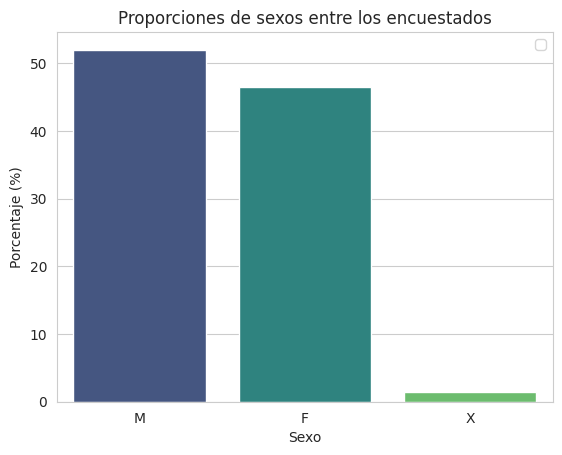

/tmp/ipykernel_13249/813035006.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ingresos, palette='viridis')


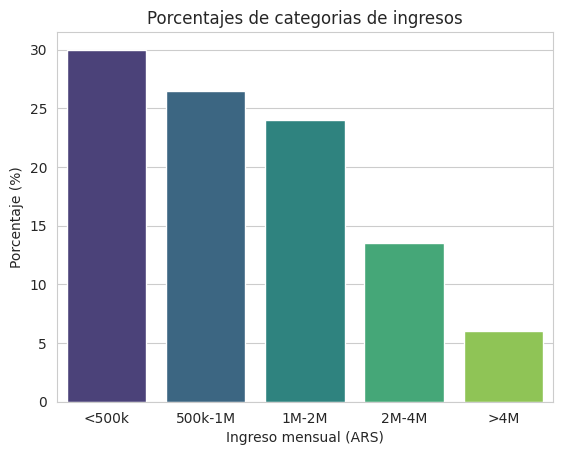

sexo
M    52.0
F    46.5
X     1.5
Name: proportion, dtype: float64
ingreso_hogar
<500k      30.0
500k-1M    26.5
1M-2M      24.0
2M-4M      13.5
>4M         6.0
Name: proportion, dtype: float64


In [85]:
sexos = data.value_counts('sexo', normalize=True) * 100
    
sns.set_style('whitegrid')
sns.barplot(sexos, palette='viridis')
plt.title('Proporciones de sexos entre los encuestados')
plt.xlabel('Sexo')
plt.ylabel('Porcentaje (%)')
plt.legend()
plt.show()

ingresos = data.value_counts('ingreso_hogar', normalize=True) * 100

sns.set_style('whitegrid')
sns.barplot(data=ingresos, palette='viridis')
plt.title('Porcentajes de categorias de ingresos')
plt.xlabel('Ingreso mensual (ARS)')
plt.ylabel('Porcentaje (%)')
plt.show()

print(sexos)
print(ingresos)


Segun lo que se puede ver en ambos graficos, la proporcion de hombres entre los encuestados es ligeramente superior a la de mujeres. Y la cantidad de encuestados para cada categoria de ingreso decrece a medida que los ingresos aumentan, siendo la categoria con mas encuestados la respectiva a ingresos menores a 500k.


PUNTO 4

In [83]:
# Filtramos para los que usan el vehiculo para trabajar y son del NOA
filtro_NOA = data[(data['region'] == 'NOA') & (data['uso_principal_auto'] == 'Trabajo')]

# a)

# Pasamos la fecha de compra a tipo datetime, luego extraemos el año y hacemos la diferencia
data['fecha_compra_N'] = pd.to_datetime(data['fecha_compra_N'])
data['anio_compra_N'] = data['fecha_compra_N'].dt.year
data['anio_compra_N'] = data['anio_compra_N'].astype(int)
años_compra = filtro_NOA['anio_compra_N'] - filtro_NOA['anio_compra_A']
años_promedio = años_compra.mean().round().astype(int)

# b)

# Para determinar lo solicitado calculamos el promedio general
años_compra_general = data['anio_compra_N'] - data['anio_compra_A']
años_promedio_general = años_compra_general.mean().round().astype(int)

print(f"En promedio, los años transcurridos entre la compra de ambos vehiculos es de {años_promedio} años.")
print(f"El promedio general de los años transcurridos entre las compras es de {años_promedio_general} años. ")

En promedio, los años transcurridos entre la compra de ambos vehiculos es de 9 años.
El promedio general de los años transcurridos entre las compras es de 11 años. 


Como vemos, los encuestados del NOA (que usan el vehiculo para trabajar) tardan MENOS en cambiar el vehiculo que el encuestado promedio.

PUNTO 5

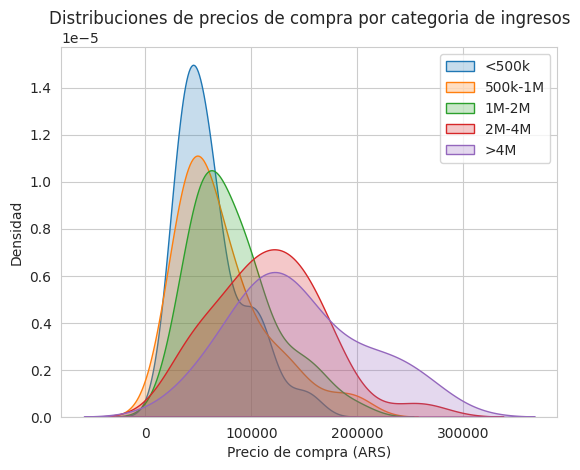

In [ ]:
sns.set_style("whitegrid")
rangos_ing = ['<500k', '500k-1M', '1M-2M', '2M-4M', '>4M']
for ing in rangos_ing:
    sns.kdeplot(
            data=data[data['ingreso_hogar'] == ing], 
            x='precio_compra_N',
            label=ing,
            fill=True,
            common_norm=False
        )

plt.title('Distribuciones de precios de compra por categoria de ingresos')
plt.xlabel('Precio de compra (ARS)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Se nota como a medida que la categoria de ingresos aumenta, los precios de compra se reparten en valores cada vez mas grandes. 

PUNTO 6

/tmp/ipykernel_13249/1660428828.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tipos_combus, palette='viridis')


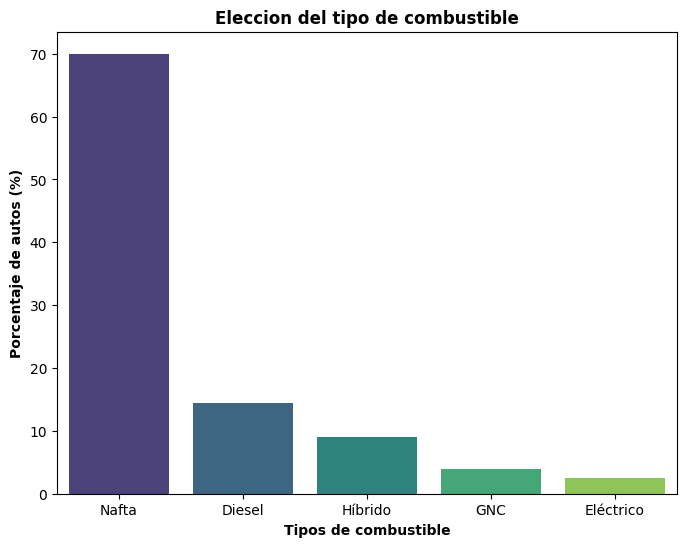

combustible_N
Nafta        70.0
Diesel       14.5
Híbrido       9.0
GNC           4.0
Eléctrico     2.5
Name: proportion, dtype: float64

In [ ]:
# a)
tipos_combus = data['combustible_N'].value_counts(normalize=True)*100
plt.figure(figsize=(8,6))
sns.barplot(data=tipos_combus, palette='viridis')
plt.title('Eleccion del tipo de combustible', fontweight='bold')
plt.ylabel('Porcentaje de autos (%)', fontweight='bold')
plt.xlabel('Tipos de combustible', fontweight='bold')
plt.show()

# b)
data['combustible_N'] = data['combustible_N'].replace('ElÃ©ctrico', 'Eléctrico')
tipos_combus


Se nota claramente como los combustibles convencionales son los preferentes de los encuestados: la Nafta (principalmente con un 70%), seguido muy por debajo del grafico, por el Diesel (con un 14.5%).

Ademas, vemos que solo el 2.5% de los encuestados eligieron un auto electrico